# Proficiency effects initial exploration

1. Previous cleaning steps
2. Merge data
3. Cleaning/ validation steps after merging
4. Map labels to knowledge and perceived level
5. Counts and proportions by knowledge level
6. Counts and proportions by perceived level

Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read datasets

In [2]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

## 1. Previous cleaning steps

In [3]:
responses = responses.rename(
    columns={"Partcipant_ID": "Participant_ID"}
)

responses["Response"] = (
    responses["Response"]
    .str.strip()
)

## 2. Merge data

In [4]:
merged_data = responses.merge(
    metadata,
    on= "Participant_ID",
    how="left"
)

## 3. Cleaning/ validation steps after merging

In [5]:
print(merged_data.shape)
print(merged_data.isnull().sum())

(336, 27)
Participant_ID     0
Focus              0
Agent_x            0
Goal_Type          0
Item               0
Item_string        0
Item_len           0
Response_tag      11
Response          11
EXP                0
n                  0
Age                0
Gender             0
Kno_Level          0
Per_Level          0
Bilingual          0
Bi_Parents         0
Multi_Kno          0
Multi_Spk          0
Immersion          0
Prof_Need          0
Prof_Use           0
Motivation         0
Agent_y            0
Distractor         0
GN_Score           0
Difficulty         0
dtype: int64


- There are no other missing values but the expected 11 ones in Responses.
- Agent appears twice in the dataset; if identical, remove one. 

Verify Agent_x and Agent_y are identical

In [6]:
(merged_data["Agent_x"] == merged_data["Agent_y"]).all()

np.True_

Drop Agent_y and rename it as Agent

In [7]:
merged_data = merged_data.drop(columns = ["Agent_y"])

merged_data = merged_data.rename(
    columns= {"Agent_x": "Agent"}
)

merged_data.shape

(336, 26)

Inspect head

In [8]:
merged_data.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,EXP,...,Bi_Parents,Multi_Kno,Multi_Spk,Immersion,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,1,...,1,0,1,0,1,1,4,4,23,3
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,1,...,1,0,1,0,1,1,4,4,23,3
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,1,...,1,0,1,0,1,1,4,4,23,3
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,1,...,1,0,1,0,1,1,4,4,23,3
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,1,...,1,0,1,0,1,1,4,4,23,3


Clean column names

In [9]:
merged_data.columns = merged_data.columns.str.strip()
metadata.columns = metadata.columns.str.strip()
responses.columns = responses.columns.str.strip()

In [10]:
merged_data.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'EXP', 'n', 'Age', 'Gender',
       'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents', 'Multi_Kno',
       'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use', 'Motivation',
       'Distractor', 'GN_Score', 'Difficulty'],
      dtype='str')

## 4. Map labels to knowledge and perceived level

Level mapping labels

In [11]:
level_mapping = {
    1: "A1",
    2: "A2.1",
    3: "A2.2",
    4: "B1.1",
    5: "B1.2",
    6: "B2.1",
    7: "B2.2",
    8: "C1",
    9: "C2"
}


In [12]:
merged_data["Kno_Level_Label"] = merged_data["Kno_Level"].map(level_mapping)
merged_data["Per_Level_Label"] = merged_data["Per_Level"].map(level_mapping)

In [13]:
merged_data.shape

(336, 28)

Order level labels

In [14]:
level_order = [
    "A1",
    "A2.1",
    "A2.2",
    "B1.1",
    "B1.2",
    "B2.1",
    "B2.2",
    "C1",
    "C2"
]

merged_data["Kno_Level_Label"] = pd.Categorical(
    merged_data["Kno_Level_Label"],
    categories=level_order,
    ordered=True
)

merged_data["Per_Level_Label"] = pd.Categorical(
    merged_data["Per_Level_Label"],
    categories=level_order,
    ordered=True
)

In [15]:
merged_data[["Kno_Level", "Kno_Level_Label", "Per_Level", "Per_Level_Label"]].tail(10)

,Kno_Level,Kno_Level_Label,Per_Level,Per_Level_Label
326,6,B2.1,5,B1.2
327,6,B2.1,5,B1.2
328,6,B2.1,5,B1.2
329,6,B2.1,5,B1.2
330,9,C2,8,C1
331,9,C2,8,C1
332,9,C2,8,C1
333,9,C2,8,C1
334,9,C2,8,C1
335,9,C2,8,C1


## 5. Counts and proportions by knowledge level

Convert nulls into explicit label temporarily

In [16]:
merged_data["Response_Full"] = (
    merged_data["Response"]
    .fillna("null")
)

In [17]:
pd.crosstab(
    merged_data["Kno_Level_Label"],
    merged_data["Response_Full"],
    margins= True
)

Response_Full,L1_transfer,L2_other,correct,null,All
Kno_Level_Label,,,,,
A1,4,0,2,0,6
B1.1,10,3,10,1,24
B1.2,1,5,0,0,6
B2.1,28,20,32,4,84
B2.2,41,22,24,3,90
C1,54,19,32,3,108
C2,11,3,4,0,18
All,149,72,104,11,336


In [18]:
kno_response_props = pd.crosstab(
    merged_data["Kno_Level_Label"],
    merged_data["Response_Full"],
    normalize= "index"
)

kno_response_props

Response_Full,L1_transfer,L2_other,correct,null
Kno_Level_Label,,,,
A1,0.666667,0.000000,0.333333,0.000000
B1.1,0.416667,0.125000,0.416667,0.041667
B1.2,0.166667,0.833333,0.000000,0.000000
B2.1,0.333333,0.238095,0.380952,0.047619
B2.2,0.455556,0.244444,0.266667,0.033333
C1,0.500000,0.175926,0.296296,0.027778
C2,0.611111,0.166667,0.222222,0.000000


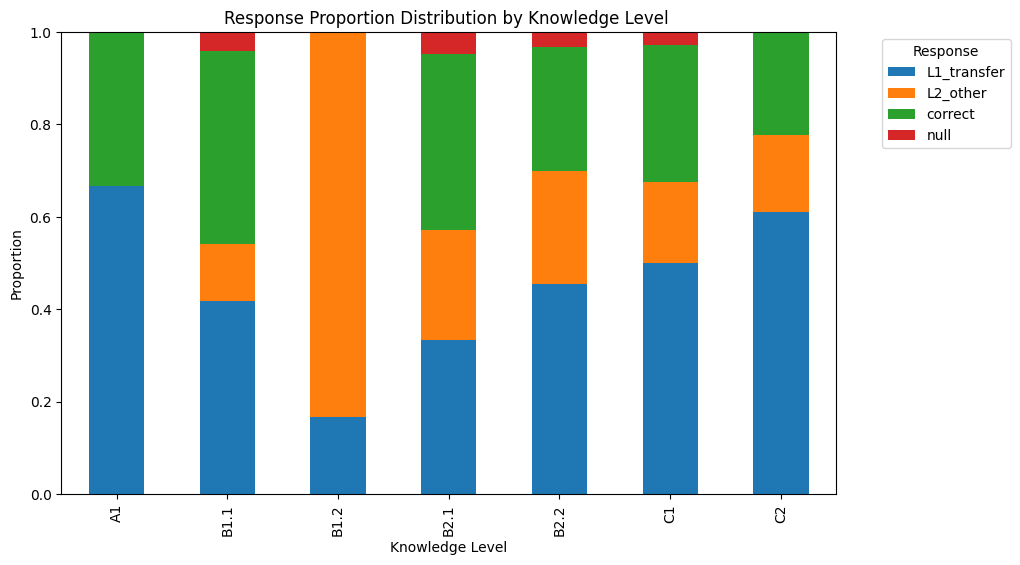

In [19]:
kno_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Knowledge Level ")
plt.xlabel("Knowledge Level")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

Leaving lower levels aside, L1_transfer seems to keep dominating, which implies that this may not simply be a case of not knowing the rule as, if so, transfer would collapse and correct responses would dominate. What we see instead is that transfer survives proficiency, like the case of levels B2.2 to C1 in which, even though correct responses increase, transfer responses do not disappear -in fact, they increase too. 

This could imply issues like processing competition, automatized transfer pathways or even cognitive load under pressure.

Perceived level, however, may actually show a different processing behaviour given that objective proficiency does not guarantee processing confidence/ resources. 

## 6. Counts and proportions by perceived level

In [20]:
pd.crosstab(
    merged_data["Per_Level_Label"],
    merged_data["Response_Full"],
    margins= True
)

Response_Full,L1_transfer,L2_other,correct,null,All
Per_Level_Label,,,,,
B1.2,7,11,19,5,42
B2.1,28,16,22,0,66
B2.2,81,35,45,1,162
C1,33,9,15,3,60
C2,0,1,3,2,6
All,149,72,104,11,336


In [21]:
per_response_props = pd.crosstab(
    merged_data["Per_Level_Label"],
    merged_data["Response_Full"],
    normalize= "index"
)

per_response_props

Response_Full,L1_transfer,L2_other,correct,null
Per_Level_Label,,,,
B1.2,0.166667,0.261905,0.452381,0.119048
B2.1,0.424242,0.242424,0.333333,0.000000
B2.2,0.500000,0.216049,0.277778,0.006173
C1,0.550000,0.150000,0.250000,0.050000
C2,0.000000,0.166667,0.500000,0.333333


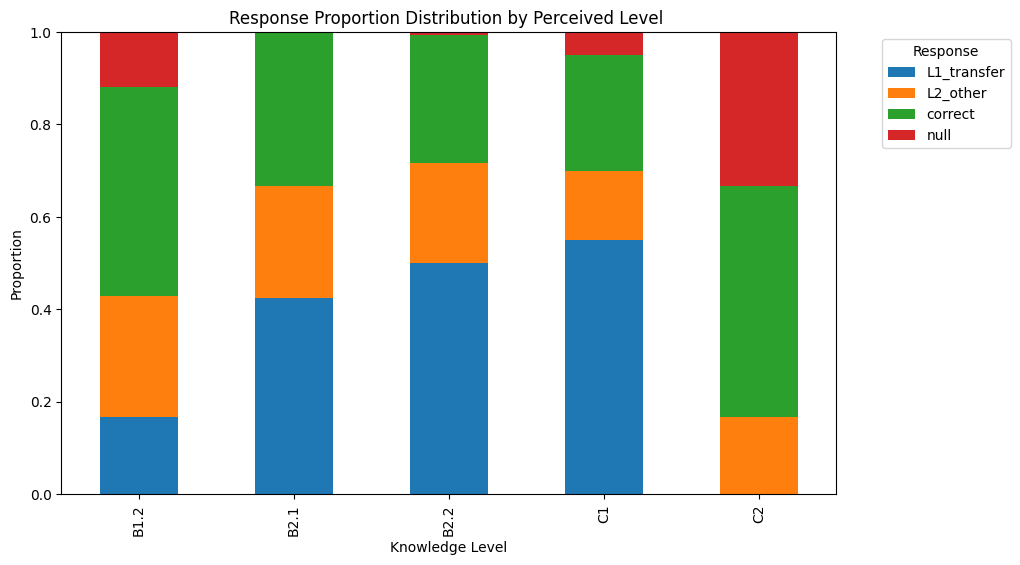

In [22]:
per_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Perceived Level ")
plt.xlabel("Knowledge Level")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

Leaving C2 aside, perceived level shows a better picture of what was previously spotted.

- Lower-level learners produce more correct responses, but they also produce more avoidance (null values) and more alternative L2 constructions or partial strategies. 
- Higher-level learners could be attempting the full counterfactual architecture; thus, the leave alternative L2 options and then transfer becomes visible and persistent. Avoidance (null values) appear again.

This takes us to exploring other variables to find out which conceptual conditions could specifically show more on this transfer persistence. 